# Credit Risk Modeling in Python

https://www.datacamp.com/courses/credit-risk-modeling-in-python

## Block 3 - Gradient Boosted Trees Using XGBoost

The primary concept behind boosting is that **a group of weak learners can become strong when combined**.

### Trees for defaults

Text(0.5, 0.98, "'prob_default' grouped by 'loan_status'")

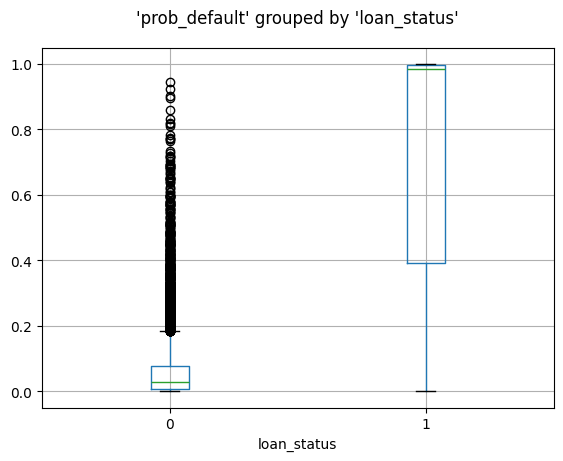

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt 

# Import Data
df = pd.read_csv("cr_loan_w2.csv")
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# Split Train-Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=610)

# Initiate XGB Tree model
treemodel = xgb.XGBClassifier().fit(X_train, y_train)

prob = treemodel.predict_proba(X_test)
preds_df = pd.DataFrame(prob[:,1], columns=["prob_default"])
preds_df = pd.concat([preds_df, y_test.reset_index(drop=True)], axis=1)

preds_df.boxplot(column="prob_default", by="loan_status")
plt.title("")
plt.suptitle("'prob_default' grouped by 'loan_status'")

### Gradient boosted portfolio performance

You've looked at predicting probability of default using both a LogisticRegression() and XGBClassifier(). You've looked at some scoring and have seen samples of the predictions, but what is the overall affect on **portfolio performance**?

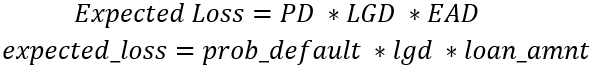

In [72]:
# Loan portfolio
data = {
    "loan_amnt": X_test["loan_amnt"],
    "lgd": 0.2 # Loss Given Default of 20% for all loans
}
portfolio = pd.DataFrame(data)

# XGB prob_default
portfolio["xgb_prob_default"] = preds_df["prob_default"]
portfolio["xgb_expected_loss"] = portfolio["xgb_prob_default"] * portfolio["lgd"] * portfolio["loan_amnt"] # XGB Expected loss

# Logistic Regression
from sklearn.linear_model import LogisticRegression
linearmodel = LogisticRegression(solver="liblinear").fit(X_train, y_train)
portfolio["lr_prob_default"] = linearmodel.predict_proba(X_test)[:,1]
portfolio["lr_expected_loss"] = portfolio["lr_prob_default"] * portfolio["lgd"] * portfolio["loan_amnt"] # LR Expected loss

# Compare Expected Loss from Default
# expected_loss = prob_default * loss_given_default (20%) * loan_amnt
print("Logistic Regression - expected_loss: " + str(np.sum(portfolio["lr_expected_loss"])))
print("XGB Tree - expected_loss: " + str(np.sum(portfolio["xgb_expected_loss"]))) # Significantly lower expected_loss!

Logistic Regression - expected_loss: 5560444.214704005
XGB Tree - expected_loss: 1738529.0391922072


### Assessing gradient boosted trees

Check the model's initial performance by looking at the metrics from the classification_report(). Keep in mind that you have not set thresholds for these models yet.

In [77]:
from sklearn.metrics import classification_report

# Predit Labels (0/1) with XGB
xgb_preds = treemodel.predict(X_test)

# Classification Report
target_names = ["Non-Default", "Default"]
print(classification_report(y_test, xgb_preds, target_names=target_names)) # Much better accuracy (0.93) than LogisticRegression (0.82)!

              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      9232
     Default       0.95      0.73      0.82      2552

    accuracy                           0.93     11784
   macro avg       0.94      0.86      0.89     11784
weighted avg       0.93      0.93      0.93     11784



### Column importance

Use the .get_booster() and .get_score() methods to get the number of times the column appears in all trees.

- Column importance is used to sometimes decide which columns to use for training
- Different sets affect the performance of the models

{'person_age': 300.0, 'person_income': 694.0, 'person_emp_length': 311.0, 'loan_amnt': 345.0, 'loan_int_rate': 516.0, 'loan_percent_income': 298.0, 'cb_person_cred_hist_length': 171.0, 'person_home_ownership_MORTGAGE': 47.0, 'person_home_ownership_OTHER': 6.0, 'person_home_ownership_OWN': 55.0, 'person_home_ownership_RENT': 59.0, 'loan_intent_DEBTCONSOLIDATION': 65.0, 'loan_intent_EDUCATION': 32.0, 'loan_intent_HOMEIMPROVEMENT': 53.0, 'loan_intent_MEDICAL': 62.0, 'loan_intent_PERSONAL': 37.0, 'loan_intent_VENTURE': 30.0, 'loan_grade_A': 1.0, 'loan_grade_B': 26.0, 'loan_grade_C': 53.0, 'loan_grade_D': 49.0, 'loan_grade_E': 27.0, 'loan_grade_F': 3.0, 'loan_grade_G': 14.0, 'cb_person_default_on_file_N': 41.0}


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

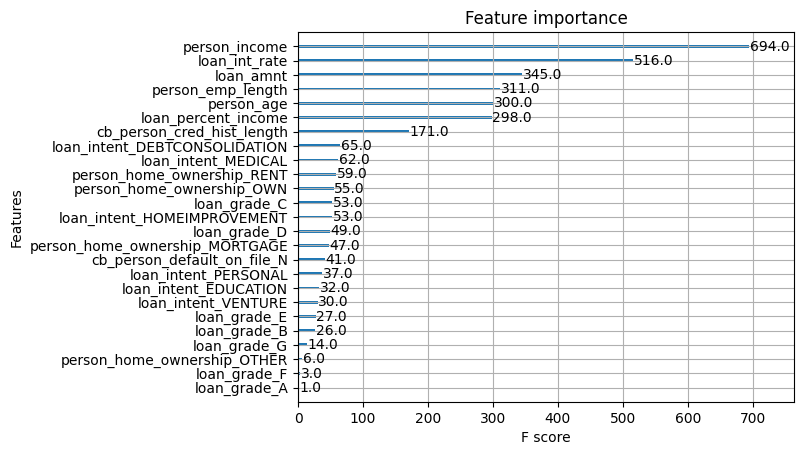

In [81]:
# Call XGB tree model
treemodel = xgb.XGBClassifier().fit(X_train, y_train)

# Columns importance
cols_importance = treemodel.get_booster().get_score()
print(cols_importance)

# Plot
xgb.plot_importance(treemodel, importance_type="weight")
# Most used features: person_income (694), loan_int_rate (516)

### Column selection and model performance

Creating the training set from different combinations of columns affects the model and the importance values of the columns.

- Let's train two models using **different sets of columns**, and compare the performances!

In [87]:
# Subset of columns: take the most used
selection = [label for label, val in cols_importance.items() if val > 100]

# New XGB model with subset of cols
X2 = df[selection]
y2 = df["loan_status"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.4, random_state=610)
treemodel2 = xgb.XGBClassifier().fit(X2_train, y2_train)

xgb_preds2 = treemodel2.predict(X2_test)

# Classification Report: all columns
print(classification_report(y_test, xgb_preds, target_names=target_names))

# Classification Report: selection
print(classification_report(y2_test, xgb_preds2, target_names=target_names)) # slightly lower accuracy

              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      9232
     Default       0.95      0.73      0.82      2552

    accuracy                           0.93     11784
   macro avg       0.94      0.86      0.89     11784
weighted avg       0.93      0.93      0.93     11784

              precision    recall  f1-score   support

 Non-Default       0.90      0.94      0.92      9232
     Default       0.75      0.62      0.68      2552

    accuracy                           0.87     11784
   macro avg       0.83      0.78      0.80     11784
weighted avg       0.87      0.87      0.87     11784



### Cross Validation

You can use cross-validation to try several smaller training and test sets which are derived from the original X_train and y_train.

**DMatrix** is an internal data structure that is used by XGBoost, which is optimized for both memory efficiency and training speed.

In [92]:
# Create the DTrain matrix for XGBoost
DTrain = xgb.DMatrix(X_train, label = y_train)

# Create the data frame of cross validations
params = {'eval_metric':'auc', "objective": "binary:logistic"}
cv_df = xgb.cv(params, DTrain, num_boost_round = 5, nfold=5, early_stopping_rounds=10)

# Print the cross validations data frame
print(cv_df) # At each fold, auc improves!

   train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0        0.901973       0.000890       0.895718      0.003861
1        0.911328       0.001263       0.904605      0.003518
2        0.917411       0.002622       0.908927      0.003196
3        0.922908       0.000725       0.913275      0.002867
4        0.926576       0.001001       0.917011      0.002731


### Limits to cross-validation testing

The test **AUC score never quite reaches 1.0** and begins to decrease slightly after 100 iterations. This is because this much cross-validation can actually cause the model to become **overfit**. So, there is a limit to how much cross-validation you should to.

   train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0        0.902301       0.001154       0.897049      0.006246
1        0.909553       0.001770       0.904131      0.006891
2        0.918339       0.001433       0.910162      0.005662
3        0.922944       0.001027       0.914434      0.005909
4        0.927270       0.000845       0.918431      0.004353


Text(0, 0.5, 'Test AUC Score')

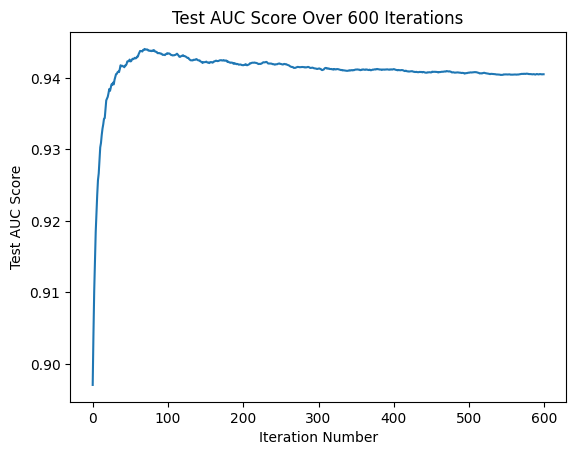

In [ ]:
# Big Cross Validation
big_cv = xgb.cv(params, DTrain, num_boost_round = 600, nfold=10, shuffle=True)
print(big_cv.head())

# Plot the test AUC scores for each iteration
plt.plot(big_cv["test-auc-mean"]) # Around 100th iteration, AUC starts decreasing!
plt.title('Test AUC Score Over 600 Iterations')
plt.xlabel('Iteration Number')
plt.ylabel('Test AUC Score')